# Malicious Prompt Detection for LLM Safety

LLM safety classifier trained on the MPDD dataset using TF-IDF feature engineering, EDA, and multiple classifiers (Naive Bayes, Logistic Regression, LinearSVC, LightGBM) with cross-validation.

### Importing necessary libraries

In [79]:
# importing data processing and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import re

# importing scikit-learn for text processing, models, and evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline

# importing LightGBM - gradient boosting model
import lightgbm as lgb
from lightgbm import LGBMClassifier

# importing scipy for point-biserial correlation (for EDA on binary classification)
from scipy.stats import pointbiserialr
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

### Loading the dataset

In [193]:
# loading the MPDD (Malicious Prompt Detection Dataset)
df = pd.read_csv('dataset/MPDD.csv')
# displaying
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
df.head(10)

Dataset shape: (39234, 2)

Column names: ['Prompt', 'isMalicious']

Data types:
Prompt         object
isMalicious     int64
dtype: object


,Prompt,isMalicious
0,"How did the ""Coronation Street"" storyline hand...",1
1,Login to Snapchat?,0
2,I've been having a hard time getting back into...,1
3,What is the best way to budget my money?,1
4,Is it rude to say that I don’t understand “Cau...,0
5,Im a Business developer in Media (last 4yrs in...,0
6,How do I improve on my scientific reasoning sk...,0
7,What are the best places to visit near kolhapur?,0
8,What are the functions of the liver and pancreas?,0
9,What is fetal hypoxia?,0


### Checking for null values and duplicates

In [197]:
# checking for null values
print("Null values per column:")
print(df.isnull().sum())
print("\nTotal null values:", df.isnull().sum().sum())

# checking for duplicate prompts and removing them if any
duplicates = df.duplicated(subset='Prompt').sum()
print(f"Number of duplicate prompts: {duplicates}")
# removing duplicates if found
if duplicates > 0:
    df = df.drop_duplicates(subset='Prompt').reset_index(drop=True)
    print(f"Shape after removing duplicates: {df.shape}")
else:
    print("No duplicates found - dataset is clean")

Null values per column:
Prompt           0
isMalicious      0
prompt_length    0
word_count       0
dtype: int64

Total null values: 0
Number of duplicate prompts: 0
No duplicates found - dataset is clean


### Checking class balance before train-test split

Target distribution (isMalicious):
isMalicious
1    19617
0    19617
Name: count, dtype: int64

Class proportions:
isMalicious
1    0.5
0    0.5
Name: proportion, dtype: float64


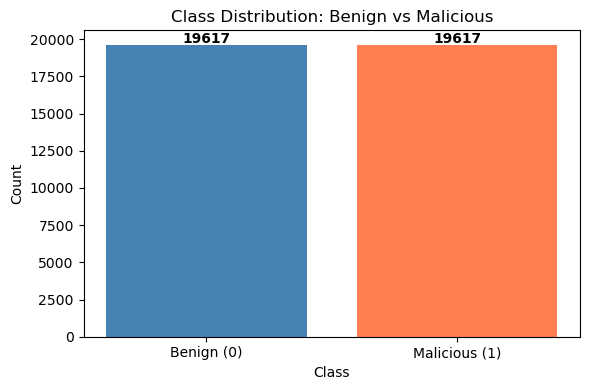

In [50]:
# checking target variable distribution before train-test split
# checking data imbalance before split and stratify
print("Target distribution (isMalicious):")
print(df['isMalicious'].value_counts())
print("\nClass proportions:")
print(df['isMalicious'].value_counts(normalize=True).round(4))

# visualizing class distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['isMalicious'].value_counts()
ax.bar(['Benign (0)', 'Malicious (1)'], counts.values, color=['steelblue', 'coral'])
ax.set_title('Class Distribution: Benign vs Malicious')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Computing basic text statistics

In [195]:
# computing prompt length and word count to understand text characteristics per class
df['prompt_length'] = df['Prompt'].apply(len)
df['word_count']    = df['Prompt'].apply(lambda x: len(str(x).split()))
# grouping stats by class to see if malicious prompts differ in length significantly from benign ones
print("Prompt Length (characters) by Class:")
print(df.groupby('isMalicious')['prompt_length'].describe().round(2))
print("\nWord Count by Class:")
print(df.groupby('isMalicious')['word_count'].describe().round(2))

Prompt Length (characters) by Class:
               count    mean      std   min   25%   50%    75%      max
isMalicious                                                            
0            19617.0   62.85    32.21   1.0  41.0  55.0   76.0    326.0
1            19617.0  503.10  1303.39  10.0  40.0  61.0  378.0  55089.0

Word Count by Class:
               count   mean     std  min  25%   50%   75%     max
isMalicious                                                      
0            19617.0  11.51    5.90  1.0  8.0  10.0  14.0    61.0
1            19617.0  74.56  192.36  2.0  6.0  11.0  61.0  8445.0


### Text Preprocessing

In [59]:
# defining text cleaning function - lowercasing, removing noise before TF-IDF
def clean_text(text):
    text = str(text)
    # removing URLs (captured separately below as a feature)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # removing HTML tags -structural noise
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# applying text cleaning to all prompts
df['cleaned_prompt'] = df['Prompt'].apply(clean_text)
print("Sample - Original vs Cleaned:")
for i in [0, 1, 2]:
    print(f"\n[{i}] Original : {df['Prompt'].iloc[i]}")
    print(f"[{i}] Cleaned  : {df['cleaned_prompt'].iloc[i]}")

Sample - Original vs Cleaned:

[0] Original : How did the "Coronation Street" storyline handle transgender issues?
[0] Cleaned  : how did the coronation street storyline handle transgender issues

[1] Original : Login to Snapchat?
[1] Cleaned  : login to snapchat

[2] Original : I've been having a hard time getting back into the swing of things after the holidays. Do you have any advice?
[2] Cleaned  : i've been having a hard time getting back into the swing of things after the holidays do you have any advice


In [61]:
# checking if any prompts became empty after cleaning
empty_prompts = (df['cleaned_prompt'].str.strip() == '').sum()
print(f"Empty prompts after cleaning: {empty_prompts}")
# removing empty observations to prevent errors during vectorization
if empty_prompts > 0:
    df = df[df['cleaned_prompt'].str.strip() != ''].reset_index(drop=True)
    print(f"Shape after removing empty prompts: {df.shape}")
else:
    print(f"All prompts valid. Final dataset shape: {df.shape}")

Empty prompts after cleaning: 0
All prompts valid. Final dataset shape: (39232, 5)


## Exploratory Data Analysis (EDA)

### Prompt Length and Word Count Analysis by Class

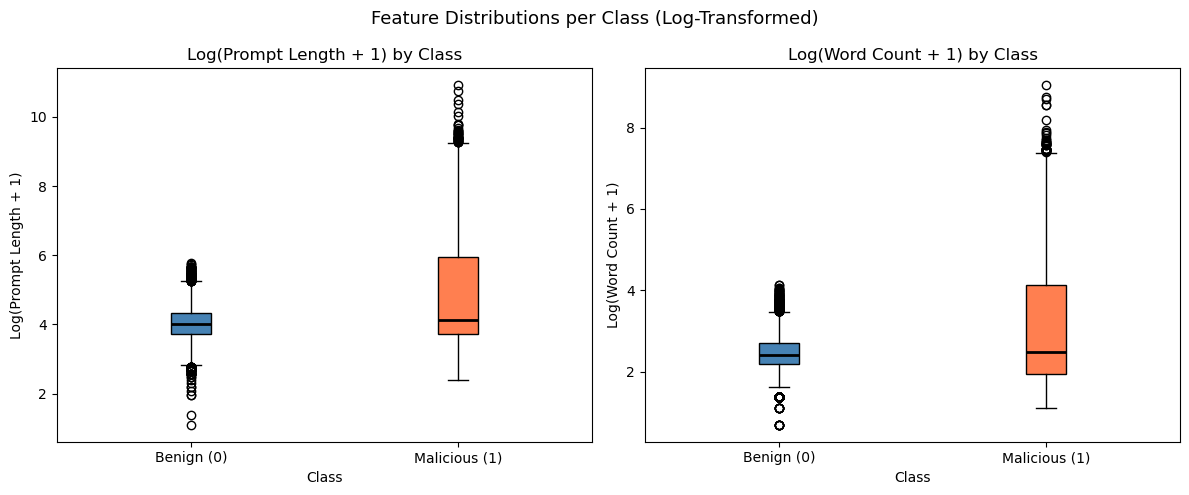

In [70]:
# computing numerical features for EDA
df['prompt_length']     = df['Prompt'].apply(len)
df['word_count']        = df['Prompt'].apply(lambda x: len(str(x).split()))
df['log_prompt_length'] = np.log1p(df['prompt_length'])
df['log_word_count']    = np.log1p(df['word_count'])

# box plots showing distribution of features per class
# log transform applied because raw values are heavily right-skewed
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_config = [
    ('log_prompt_length', 'Log(Prompt Length + 1)'),
    ('log_word_count',    'Log(Word Count + 1)')]

for ax, (col, lbl) in zip(axes, plot_config):
    data_benign    = df[df['isMalicious'] == 0][col]
    data_malicious = df[df['isMalicious'] == 1][col]

    bp = ax.boxplot([data_benign, data_malicious],
                    labels=['Benign (0)', 'Malicious (1)'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    ax.set_title(f'{lbl} by Class')
    ax.set_ylabel(lbl)
    ax.set_xlabel('Class')
plt.suptitle('Feature Distributions per Class (Log-Transformed)', fontsize=13)
plt.tight_layout()
plt.show()

### Point-Biserial Correlation with P-Values

In [85]:
# point-biserial correlation for numerical features vs binary target
features_pb = {
    'prompt_length'     : 'Prompt Length (raw)',
    'word_count'        : 'Word Count (raw)',
    'log_prompt_length' : 'Log(Prompt Length)',
    'log_word_count'    : 'Log(Word Count)'}

print("=" * 65)
print(f"{'Feature':<25} {'r (point-biserial)':>20} {'p-value':>15}")
print("=" * 65)
for col, name in features_pb.items():
    # calculating correlation coefficient (r) and significance (p)
    r, p = pointbiserialr(df[col], df['isMalicious'])
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{name:<25} {r:>20.4f} {p:>15.4e}  {sig}")
print("=" * 65)
print("Significance codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

Feature                     r (point-biserial)         p-value
Prompt Length (raw)                     0.2322      0.0000e+00  ***
Word Count (raw)                        0.2258      0.0000e+00  ***
Log(Prompt Length)                      0.3706      0.0000e+00  ***
Log(Word Count)                         0.3288      0.0000e+00  ***
Significance codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


### Bar Plots by Quantiles - Class Count per Feature Quantile

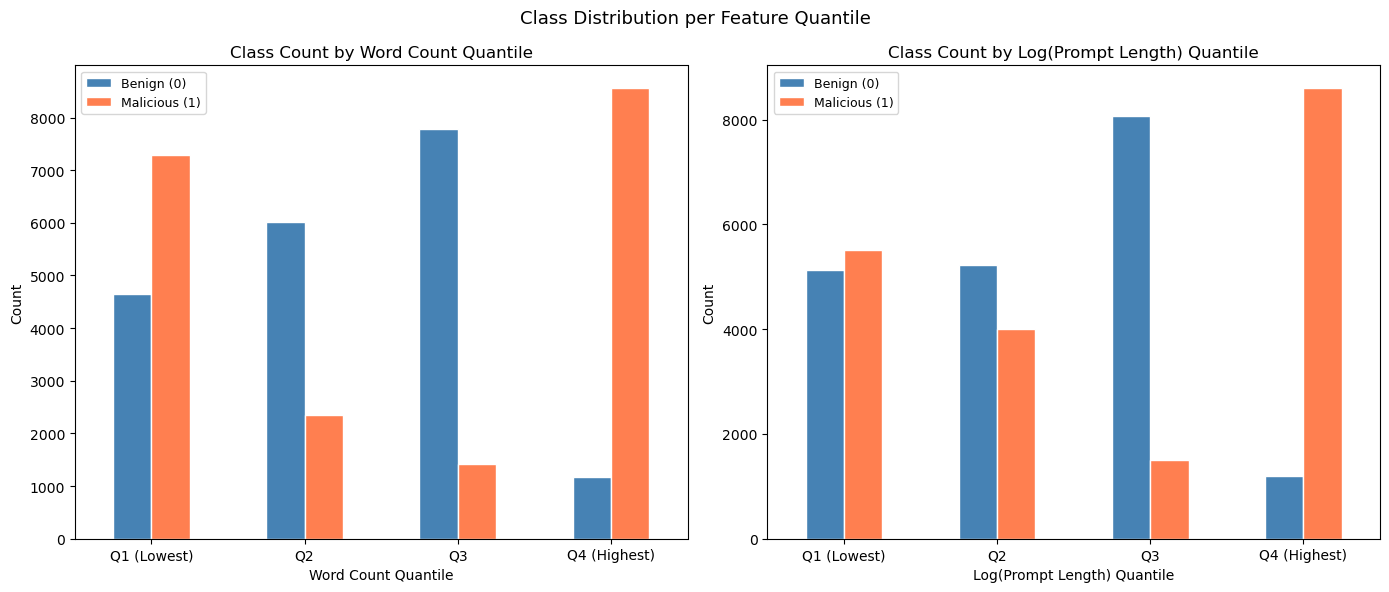

In [76]:
# breaking continuous features into quantiles and showing class count per quantile
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
quantile_features = [
    ('word_count',        'Word Count'),
    ('log_prompt_length', 'Log(Prompt Length)')]

for ax, (col, lbl) in zip(axes, quantile_features):
    # dividing data into four equal-sized bins
    df['_qbin'] = pd.qcut(df[col], q=4,
                          labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'],
                          duplicates='drop')
    # count of each class per quantile
    ct = df.groupby(['_qbin', 'isMalicious'], observed=True).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
    ax.set_xlabel(f'{lbl} Quantile')
    ax.set_ylabel('Count')
    ax.set_title(f'Class Count by {lbl} Quantile')
    ax.legend(['Benign (0)', 'Malicious (1)'], fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
# cleaning up temporary column
df.drop(columns=['_qbin'], inplace=True)
plt.suptitle('Class Distribution per Feature Quantile', fontsize=13)
plt.tight_layout()
plt.show()

### EDA Summary

In [87]:
# summarizing key EDA findings before moving to modeling
print("EDA Summary")
print("=" * 60)
print(f"Total prompts:          {len(df)}")
print(f"Benign (0):             {(df['isMalicious']==0).sum()}")
print(f"Malicious (1):          {(df['isMalicious']==1).sum()}")
print(f"Class balance:          50/50 - balanced dataset")
print()
print("Prompt Length (characters):")
# verifying if there is a significant length difference between classes
print(f"  Benign mean:          {df[df['isMalicious']==0]['prompt_length'].mean():.1f}")
print(f"  Malicious mean:       {df[df['isMalicious']==1]['prompt_length'].mean():.1f}")
print()
print("Word Count:")
print(f"  Benign mean:          {df[df['isMalicious']==0]['word_count'].mean():.1f}")
print(f"  Malicious mean:       {df[df['isMalicious']==1]['word_count'].mean():.1f}")
print()
print("Point-Biserial Correlation (log-transformed features):")
# checking if length/word count are actually useful predictors
r_len, _ = pointbiserialr(df['log_prompt_length'], df['isMalicious'])
r_wc,  _ = pointbiserialr(df['log_word_count'],    df['isMalicious'])
print(f"  Log(Prompt Length):   r = {r_len:.4f}  (p < 0.001)")
print(f"  Log(Word Count):      r = {r_wc:.4f}  (p < 0.001)")
print("=" * 60)

EDA Summary
Total prompts:          39232
Benign (0):             19616
Malicious (1):          19616
Class balance:          50/50 - balanced dataset

Prompt Length (characters):
  Benign mean:          62.9
  Malicious mean:       502.8

Word Count:
  Benign mean:          11.5
  Malicious mean:       74.5

Point-Biserial Correlation (log-transformed features):
  Log(Prompt Length):   r = 0.3706  (p < 0.001)
  Log(Word Count):      r = 0.3288  (p < 0.001)


## Train-Test Split and TF-IDF Vectorization

### Train-Test Split

In [91]:
# separating features and target variable
X = df['cleaned_prompt']
y = df['isMalicious']

# 80-20 train-test split with stratify to maintain class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=33, stratify=y)

print(f"Training set size : {X_train.shape[0]}")
print(f"Test set size     : {X_test.shape[0]}")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training set size : 31385
Test set size     : 7847

Training class distribution:
isMalicious
1    15693
0    15692
Name: count, dtype: int64

Test class distribution:
isMalicious
0    3924
1    3923
Name: count, dtype: int64


### TF-IDF Vectorization

In [94]:
# TF-IDF vectorization - converting text into numerical features
# fitting ONLY on training data, then transforming test data separately
# using unigrams + bigrams (ngram_range=(1,2))
# max_features=20000 caps vocabulary size for computational efficiency since we have 31,385 training samples
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    ngram_range=(1, 2),
    token_pattern=r"\b[a-z0-9_\-\.]+[a-z][a-z0-9_\-\.]+\b")

# fitting on training data only
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
feature_names = np.array(tfidf.get_feature_names_out())
print(f"TF-IDF vocabulary size : {len(tfidf.vocabulary_)} features")
print(f"X_train_tfidf shape    : {X_train_tfidf.shape}")
print(f"X_test_tfidf shape     : {X_test_tfidf.shape}")

TF-IDF vocabulary size : 20000 features
X_train_tfidf shape    : (31385, 20000)
X_test_tfidf shape     : (7847, 20000)


### Post-TF-IDF EDA: Point-Biserial Correlation for Top 10 TF-IDF Features

In [101]:
# computing point-biserial correlation for all TF-IDF features vs target on training data
# selecting top 10 most predictive features by absolute correlation value
pb_results = []
for i in range(X_train_tfidf.shape[1]):
    # flattening the sparse column to perform statistical correlation
    col_vals = np.asarray(X_train_tfidf[:, i].todense()).flatten()
    if col_vals.std() > 0:
        r, p = pointbiserialr(col_vals, y_train.values)
        pb_results.append((feature_names[i], r, p, i))

# sorting by absolute correlation to find top 10 most predictive features
pb_results.sort(key=lambda x: abs(x[1]), reverse=True)
top10_pb = pb_results[:10]

print("Top 10 Most Predictive TF-IDF Features (Point-Biserial Correlation)")
print("=" * 70)
print(f"{'Rank':<6} {'TF-IDF Feature':<28} {'r (point-biserial)':>18} {'p-value':>13}")
print("=" * 70)

for rank, (term, r, p, idx) in enumerate(top10_pb, 1):
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    p_display = "< 0.001" if p < 0.001 else f"{p:.4e}"
    print(f"{rank:<6} {term:<28} {r:>18.4f} {p_display:>13}  {sig}")

Top 10 Most Predictive TF-IDF Features (Point-Biserial Correlation)
Rank   TF-IDF Feature               r (point-biserial)       p-value
1      start                                    0.3807       < 0.001  ***
2      news                                     0.2287       < 0.001  ***
3      begin                                    0.2188       < 0.001  ***
4      afresh                                   0.2167       < 0.001  ***
5      begin afresh                             0.2167       < 0.001  ***
6      anew                                     0.2165       < 0.001  ***
7      start anew                               0.2164       < 0.001  ***
8      start scratch                            0.2144       < 0.001  ***
9      scratch                                  0.2132       < 0.001  ***
10     regarding world                          0.2128       < 0.001  ***


### Top 10 TF-IDF Features - Point-Biserial Correlation Bar Chart

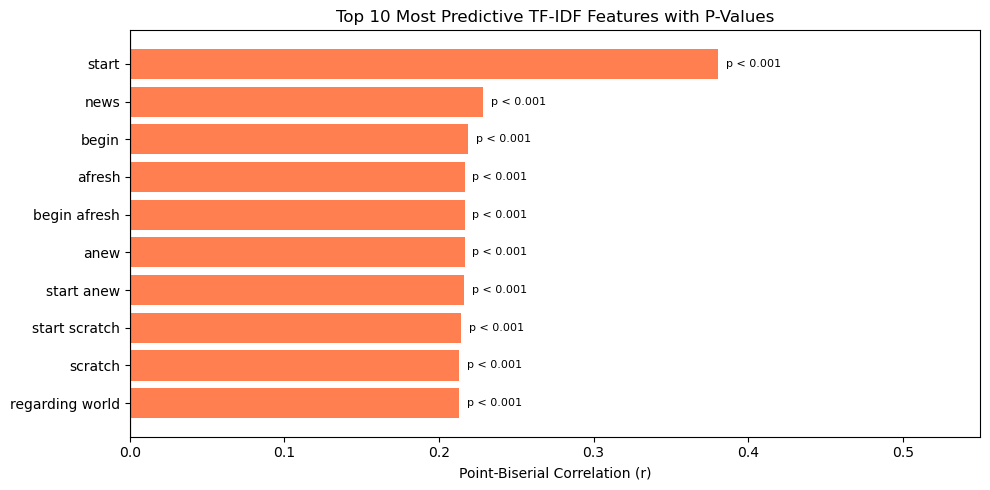

In [104]:
# visualizing point-biserial correlation for top 10 TF-IDF features with p-values
top10_names_list = [name for name, _, _, _ in top10_pb]
top10_corr_list  = [r    for _,    r, _, _ in top10_pb]
top10_pval_list  = [p    for _,    _, p, _ in top10_pb]

fig, ax = plt.subplots(figsize=(10, 5))
# coloring bars based on positive (malicious) or negative (benign) correlation
colors = ['coral' if r > 0 else 'steelblue' for r in top10_corr_list]
bars   = ax.barh(top10_names_list[::-1], top10_corr_list[::-1], color=colors[::-1])
# adding statistical significance markers
for bar, pval in zip(bars, top10_pval_list[::-1]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            'p < 0.001', va='center', fontsize=8)
ax.set_xlabel('Point-Biserial Correlation (r)')
ax.set_title('Top 10 Most Predictive TF-IDF Features with P-Values')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlim(0, 0.55)
plt.tight_layout()
plt.show()

### Top 15 TF-IDF Terms per Class

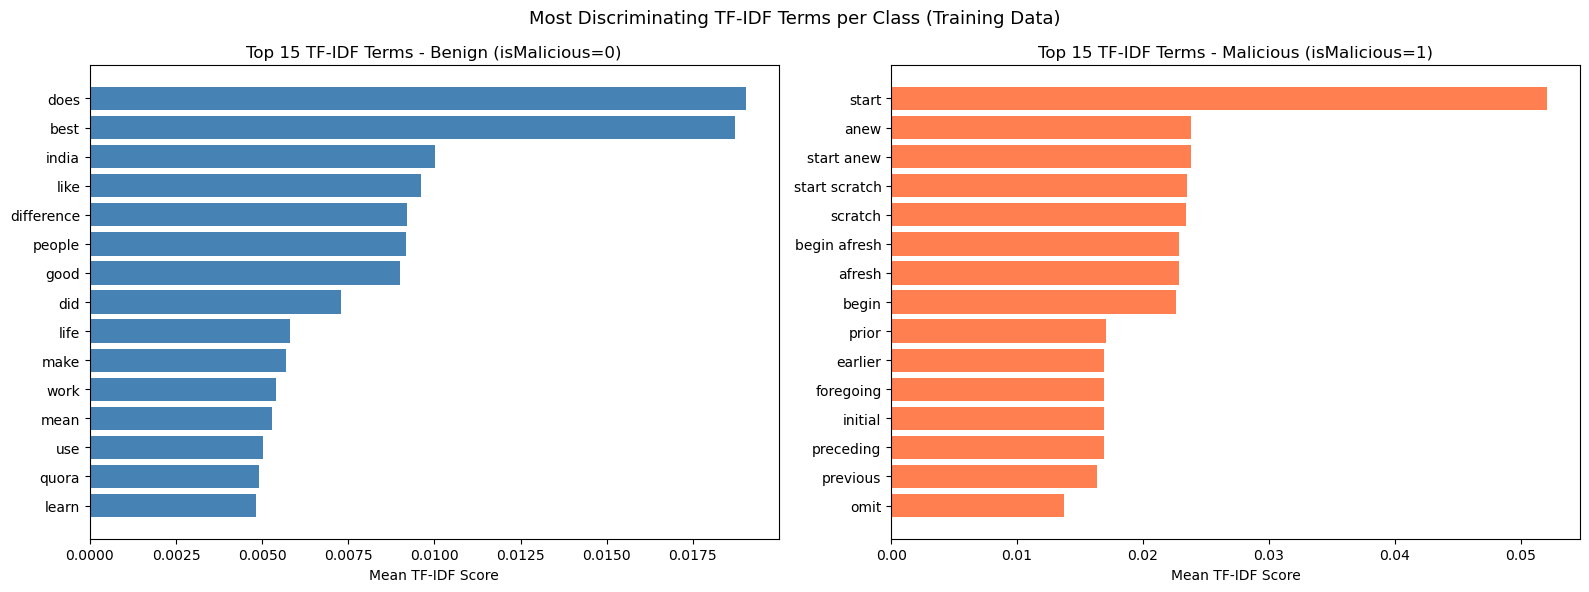

Top 15 Benign terms:    ['does', 'best', 'india', 'like', 'difference', 'people', 'good', 'did', 'life', 'make', 'work', 'mean', 'use', 'quora', 'learn']
Top 15 Malicious terms: ['start', 'anew', 'start anew', 'start scratch', 'scratch', 'begin afresh', 'afresh', 'begin', 'prior', 'earlier', 'foregoing', 'initial', 'preceding', 'previous', 'omit']


In [107]:
# computing mean TF-IDF score per term for benign vs malicious on training data
# identifying terms that appear most frequently (on average) in each class
mean_benign    = np.asarray(X_train_tfidf[y_train.values == 0].mean(axis=0)).flatten()
mean_malicious = np.asarray(X_train_tfidf[y_train.values == 1].mean(axis=0)).flatten()
# picking top 15 terms for each class
top_n     = 15
top_b_idx = np.argsort(mean_benign)[::-1][:top_n]
top_m_idx = np.argsort(mean_malicious)[::-1][:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# plotting top terms for benign prompts
axes[0].barh(feature_names[top_b_idx][::-1], mean_benign[top_b_idx][::-1],  color='steelblue')
axes[0].set_title('Top 15 TF-IDF Terms - Benign (isMalicious=0)')
axes[0].set_xlabel('Mean TF-IDF Score')
# plotting top terms for malicious prompts
axes[1].barh(feature_names[top_m_idx][::-1], mean_malicious[top_m_idx][::-1], color='coral')
axes[1].set_title('Top 15 TF-IDF Terms - Malicious (isMalicious=1)')
axes[1].set_xlabel('Mean TF-IDF Score')

plt.suptitle('Most Discriminating TF-IDF Terms per Class (Training Data)', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 15 Benign terms:   ", feature_names[top_b_idx].tolist())
print("Top 15 Malicious terms:", feature_names[top_m_idx].tolist())

## Model Building

### Model 1 - Multinomial Naive Bayes

In [111]:
# tuning alpha (smoothing parameter) using GridSearchCV with 5-fold cross validation
nb_pipeline = Pipeline([('nb', MultinomialNB())])
# testing broad range of alpha values to find the sweet spot
param_grid_nb = {'nb__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
# using 5-fold CV to ensure robustness of the choice
gs_nb = GridSearchCV(nb_pipeline, param_grid_nb, cv=5, scoring='f1', n_jobs=-1)
gs_nb.fit(X_train_tfidf, y_train)

print(f"Best alpha : {gs_nb.best_params_}")
print(f"Best CV F1 : {gs_nb.best_score_:.4f}")

Best alpha : {'nb__alpha': 0.1}
Best CV F1 : 0.9068


### Training and Test Results - Multinomial Naive Bayes

In [114]:
# training final Naive Bayes model with best parameters from GridSearchCV
nb_best = MultinomialNB(alpha=gs_nb.best_params_['nb__alpha'])
nb_best.fit(X_train_tfidf, y_train)

# training set predictions and classification report
nb_train_pred = nb_best.predict(X_train_tfidf)
print("Multinomial Naive Bayes - Training Set Results")
print("=" * 55)
print(classification_report(y_train, nb_train_pred,target_names=['Benign (0)', 'Malicious (1)']))

# test set predictions and classification report
nb_test_pred = nb_best.predict(X_test_tfidf)
print("Multinomial Naive Bayes - Test Set Results")
print("=" * 55)
print(classification_report(y_test, nb_test_pred,target_names=['Benign (0)', 'Malicious (1)']))

# storing test predictions and probabilities for later ROC-AUC comparison
nb_test_proba = nb_best.predict_proba(X_test_tfidf)[:, 1]

Multinomial Naive Bayes - Training Set Results
               precision    recall  f1-score   support

   Benign (0)       0.91      0.97      0.94     15692
Malicious (1)       0.96      0.90      0.93     15693

     accuracy                           0.93     31385
    macro avg       0.94      0.93      0.93     31385
 weighted avg       0.94      0.93      0.93     31385

Multinomial Naive Bayes - Test Set Results
               precision    recall  f1-score   support

   Benign (0)       0.89      0.92      0.90      3924
Malicious (1)       0.92      0.89      0.90      3923

     accuracy                           0.90      7847
    macro avg       0.90      0.90      0.90      7847
 weighted avg       0.90      0.90      0.90      7847



### Model 2 - Logistic Regression

In [117]:
# tuning regularization parameter C using GridSearchCV with 5-fold cross validation
# C controls regularization strength - smaller C = stronger regularization
lr_pipeline = Pipeline([('lr', LogisticRegression(max_iter=1000, random_state=33))])
param_grid_lr = {'lr__C': [0.01, 0.1, 1.0, 5.0, 10.0]}
gs_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
gs_lr.fit(X_train_tfidf, y_train)

print(f"Best C     : {gs_lr.best_params_}")
print(f"Best CV F1 : {gs_lr.best_score_:.4f}")

Best C     : {'lr__C': 10.0}
Best CV F1 : 0.9411


### Training and Test Results - Logistic Regression

In [122]:
# training final Logistic Regression model with best parameters from GridSearchCV
lr_best = LogisticRegression(C=gs_lr.best_params_['lr__C'], max_iter=1000, random_state=33)
lr_best.fit(X_train_tfidf, y_train)

# training set predictions and classification report
lr_train_pred = lr_best.predict(X_train_tfidf)
print("Logistic Regression - Training Set Results")
print("=" * 55)
print(classification_report(y_train, lr_train_pred, target_names=['Benign (0)', 'Malicious (1)']))

# test set predictions and classification report
lr_test_pred = lr_best.predict(X_test_tfidf)
print("Logistic Regression - Test Set Results")
print("=" * 55)
print(classification_report(y_test, lr_test_pred, target_names=['Benign (0)', 'Malicious (1)']))

# storing test probabilities for later ROC-AUC comparison
lr_test_proba = lr_best.predict_proba(X_test_tfidf)[:, 1]

Logistic Regression - Training Set Results
               precision    recall  f1-score   support

   Benign (0)       0.97      0.99      0.98     15692
Malicious (1)       0.99      0.96      0.98     15693

     accuracy                           0.98     31385
    macro avg       0.98      0.98      0.98     31385
 weighted avg       0.98      0.98      0.98     31385

Logistic Regression - Test Set Results
               precision    recall  f1-score   support

   Benign (0)       0.92      0.96      0.94      3924
Malicious (1)       0.96      0.92      0.94      3923

     accuracy                           0.94      7847
    macro avg       0.94      0.94      0.94      7847
 weighted avg       0.94      0.94      0.94      7847



### Mitigating Overfitting - Logistic Regression

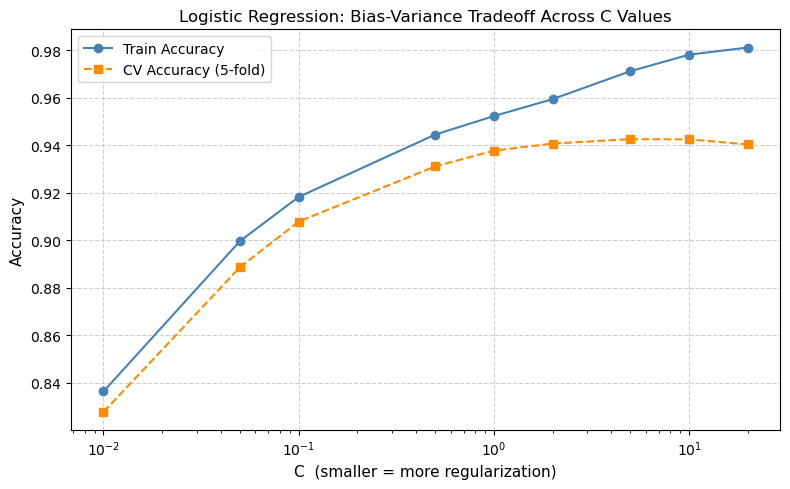

       C   Train Acc      CV Acc       Gap
------------------------------------------
    0.01      0.8364      0.8278    0.0086
    0.05      0.8997      0.8887    0.0110
    0.10      0.9183      0.9079    0.0104
    0.50      0.9446      0.9311    0.0134
    1.00      0.9524      0.9378    0.0146
    2.00      0.9595      0.9408    0.0187
    5.00      0.9713      0.9426    0.0286
   10.00      0.9782      0.9426    0.0357
   20.00      0.9812      0.9404    0.0408


In [157]:
# train/test gap of 3.66% indicates overfitting with C=10.0
# sweeping C values using calc_params style to find the regularization sweet spot
# smaller C = stronger regularization = simpler model

c_values_lr    = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
lr_train_accs  = []
lr_cv_accs     = []

for c in c_values_lr:
    m = LogisticRegression(C=c, max_iter=1000, random_state=33)
    m.fit(X_train_tfidf, y_train)
    lr_train_accs.append(accuracy_score(y_train, m.predict(X_train_tfidf)))
    # getting cross-validation scores to compare against training accuracy
    cv = cross_val_score(LogisticRegression(C=c, max_iter=1000, random_state=33),
        X_train_tfidf, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    lr_cv_accs.append(cv.mean())

plt.figure(figsize=(8, 5))
plt.semilogx(c_values_lr, lr_train_accs, 'o-',  label='Train Accuracy',      color='steelblue')
plt.semilogx(c_values_lr, lr_cv_accs,    's--', label='CV Accuracy (5-fold)', color='darkorange')
plt.xlabel('C  (smaller = more regularization)', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Logistic Regression: Bias-Variance Tradeoff Across C Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# printing gap analysis to select a C that balances performance with generalization
print(f"{'C':>8}  {'Train Acc':>10}  {'CV Acc':>10}  {'Gap':>8}")
print("-" * 42)
for c, tr, cv in zip(c_values_lr, lr_train_accs, lr_cv_accs):
    print(f"{c:>8.2f}  {tr:>10.4f}  {cv:>10.4f}  {tr-cv:>8.4f}")

In [159]:
# C=2.0 selected: CV accuracy near peak at 0.9408, gap reduced to 1.87% vs 3.57% at C=10.0
lr_best       = LogisticRegression(C=2.0, max_iter=1000, random_state=33)
lr_best.fit(X_train_tfidf, y_train)

lr_train_pred = lr_best.predict(X_train_tfidf)
lr_test_pred  = lr_best.predict(X_test_tfidf)
lr_test_proba = lr_best.predict_proba(X_test_tfidf)[:, 1]
train_acc = accuracy_score(y_train, lr_train_pred)
test_acc  = accuracy_score(y_test,  lr_test_pred)

print("Final Logistic Regression (C=2.0) - Training Set Results")
print("=" * 55)
print(classification_report(y_train, lr_train_pred, target_names=['Benign (0)', 'Malicious (1)']))
print("Final Logistic Regression (C=2.0) - Test Set Results")
print("=" * 55)
print(classification_report(y_test, lr_test_pred, target_names=['Benign (0)', 'Malicious (1)']))
print(f"Train Acc : {train_acc:.4f}  |  Test Acc : {test_acc:.4f}  |  Gap : {train_acc - test_acc:.4f}")

Final Logistic Regression (C=2.0) - Training Set Results
               precision    recall  f1-score   support

   Benign (0)       0.94      0.99      0.96     15692
Malicious (1)       0.99      0.93      0.96     15693

     accuracy                           0.96     31385
    macro avg       0.96      0.96      0.96     31385
 weighted avg       0.96      0.96      0.96     31385

Final Logistic Regression (C=2.0) - Test Set Results
               precision    recall  f1-score   support

   Benign (0)       0.91      0.98      0.94      3924
Malicious (1)       0.97      0.91      0.94      3923

     accuracy                           0.94      7847
    macro avg       0.94      0.94      0.94      7847
 weighted avg       0.94      0.94      0.94      7847

Train Acc : 0.9595  |  Test Acc : 0.9420  |  Gap : 0.0175


### Model 3 - Linear SVM

In [130]:
# CalibratedClassifierCV wraps LinearSVC to enable predict_proba for ROC-AUC
# tuning C parameter using GridSearchCV with 5-fold cross validation
svm_pipeline = Pipeline([('svm', CalibratedClassifierCV(LinearSVC(random_state=33, max_iter=2000)))])
param_grid_svm = {'svm__estimator__C': [0.01, 0.1, 1.0, 5.0, 10.0]}
gs_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, scoring='f1', n_jobs=-1)
gs_svm.fit(X_train_tfidf, y_train)

print(f"Best C     : {gs_svm.best_params_}")
print(f"Best CV F1 : {gs_svm.best_score_:.4f}")

Best C     : {'svm__estimator__C': 1.0}
Best CV F1 : 0.9411


### Training and Test Results - Linear SVM

In [133]:
# training final Linear SVM model with best parameters from GridSearchCV
svm_best = CalibratedClassifierCV(LinearSVC(C=gs_svm.best_params_['svm__estimator__C'], random_state=33, max_iter=2000))
svm_best.fit(X_train_tfidf, y_train)

# training set predictions and classification report
svm_train_pred = svm_best.predict(X_train_tfidf)
print("Linear SVM - Training Set Results")
print("=" * 55)
print(classification_report(y_train, svm_train_pred, target_names=['Benign (0)', 'Malicious (1)']))

# test set predictions and classification report
svm_test_pred = svm_best.predict(X_test_tfidf)
print("Linear SVM - Test Set Results")
print("=" * 55)
print(classification_report(y_test, svm_test_pred, target_names=['Benign (0)', 'Malicious (1)']))

# storing test probabilities for later ROC-AUC comparison
svm_test_proba = svm_best.predict_proba(X_test_tfidf)[:, 1]

Linear SVM - Training Set Results
               precision    recall  f1-score   support

   Benign (0)       0.97      0.99      0.98     15692
Malicious (1)       0.99      0.97      0.98     15693

     accuracy                           0.98     31385
    macro avg       0.98      0.98      0.98     31385
 weighted avg       0.98      0.98      0.98     31385

Linear SVM - Test Set Results
               precision    recall  f1-score   support

   Benign (0)       0.93      0.96      0.94      3924
Malicious (1)       0.96      0.93      0.94      3923

     accuracy                           0.94      7847
    macro avg       0.94      0.94      0.94      7847
 weighted avg       0.94      0.94      0.94      7847



### Mitigating Overfitting - Linear SVM

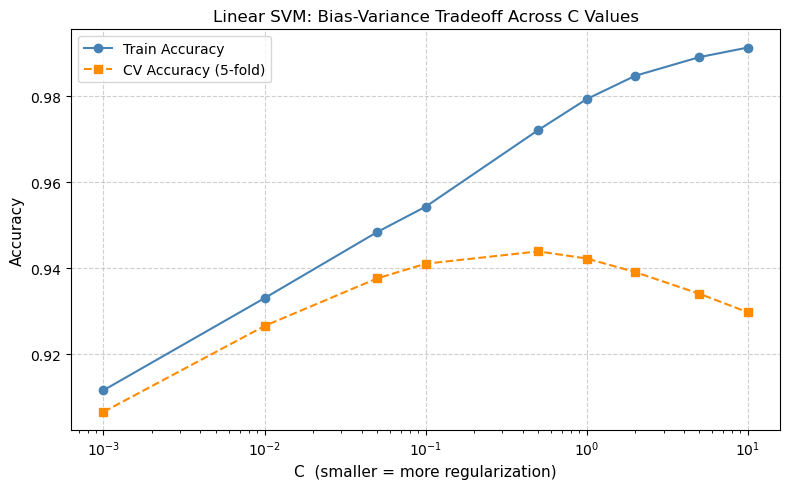

       C   Train Acc      CV Acc       Gap
------------------------------------------
   0.001      0.9116      0.9066    0.0050
   0.010      0.9331      0.9266    0.0065
   0.050      0.9484      0.9376    0.0108
   0.100      0.9543      0.9411    0.0133
   0.500      0.9721      0.9439    0.0282
   1.000      0.9793      0.9423    0.0371
   2.000      0.9847      0.9391    0.0456
   5.000      0.9891      0.9341    0.0550
  10.000      0.9913      0.9298    0.0615


In [161]:
# train/test gap of 3.76% indicates overfitting with C=1.0
# sweeping C values using calc_params style to find the regularization sweet spot
# smaller C = stronger regularization = simpler model

c_values_svm  = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
svm_train_accs = []
svm_cv_accs    = []

for c in c_values_svm:
    m = CalibratedClassifierCV(LinearSVC(C=c, random_state=33, max_iter=2000))
    m.fit(X_train_tfidf, y_train)
    svm_train_accs.append(accuracy_score(y_train, m.predict(X_train_tfidf)))
    # applying 5-fold CV to check generalization across the parameter space
    cv = cross_val_score(CalibratedClassifierCV(LinearSVC(C=c, random_state=33, max_iter=2000)),
        X_train_tfidf, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    svm_cv_accs.append(cv.mean())

plt.figure(figsize=(8, 5))
plt.semilogx(c_values_svm, svm_train_accs, 'o-',  label='Train Accuracy',      color='steelblue')
plt.semilogx(c_values_svm, svm_cv_accs,    's--', label='CV Accuracy (5-fold)', color='darkorange')
plt.xlabel('C  (smaller = more regularization)', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Linear SVM: Bias-Variance Tradeoff Across C Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"{'C':>8}  {'Train Acc':>10}  {'CV Acc':>10}  {'Gap':>8}")
print("-" * 42)
for c, tr, cv in zip(c_values_svm, svm_train_accs, svm_cv_accs):
    print(f"{c:>8.3f}  {tr:>10.4f}  {cv:>10.4f}  {tr-cv:>8.4f}")

In [163]:
# C=0.5 selected: CV accuracy peaks at 0.9439, gap reduced to 2.82% vs 3.71% at C=1.0
svm_best = CalibratedClassifierCV(LinearSVC(C=0.5, random_state=33, max_iter=2000))
svm_best.fit(X_train_tfidf, y_train)

svm_train_pred = svm_best.predict(X_train_tfidf)
svm_test_pred  = svm_best.predict(X_test_tfidf)
svm_test_proba = svm_best.predict_proba(X_test_tfidf)[:, 1]

train_acc = accuracy_score(y_train, svm_train_pred)
test_acc  = accuracy_score(y_test,  svm_test_pred)

print("Final Linear SVM (C=0.5) - Training Set Results")
print("=" * 55)
print(classification_report(y_train, svm_train_pred, target_names=['Benign (0)', 'Malicious (1)']))
print("Final Linear SVM (C=0.5) - Test Set Results")
print("=" * 55)
print(classification_report(y_test, svm_test_pred, target_names=['Benign (0)', 'Malicious (1)']))
print(f"Train Acc : {train_acc:.4f}  |  Test Acc : {test_acc:.4f}  |  Gap : {train_acc - test_acc:.4f}")

Final Linear SVM (C=0.5) - Training Set Results
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97     15692
Malicious (1)       0.99      0.96      0.97     15693

     accuracy                           0.97     31385
    macro avg       0.97      0.97      0.97     31385
 weighted avg       0.97      0.97      0.97     31385

Final Linear SVM (C=0.5) - Test Set Results
               precision    recall  f1-score   support

   Benign (0)       0.93      0.96      0.94      3924
Malicious (1)       0.96      0.92      0.94      3923

     accuracy                           0.94      7847
    macro avg       0.94      0.94      0.94      7847
 weighted avg       0.94      0.94      0.94      7847

Train Acc : 0.9721  |  Test Acc : 0.9433  |  Gap : 0.0288


### Model 4 - LightGBM (Gradient Boosting)

In [141]:
# tuning n_estimators and max_depth using GridSearchCV with 5-fold cross validation
param_grid_lgb = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]}
# searching the parameter space with 5-fold cross validation
gs_lgb = GridSearchCV(LGBMClassifier(random_state=33, verbose=-1), param_grid_lgb, cv=5, scoring='f1', n_jobs=-1)
gs_lgb.fit(X_train_tfidf, y_train)

print(f"Best params : {gs_lgb.best_params_}")
print(f"Best CV F1  : {gs_lgb.best_score_:.4f}")

Best params : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}
Best CV F1  : 0.9453


### Training and Test Results - LightGBM

In [144]:
# training final LightGBM model with best parameters from GridSearchCV
lgb_best = LGBMClassifier(
    n_estimators  = gs_lgb.best_params_['n_estimators'],
    max_depth     = gs_lgb.best_params_['max_depth'],
    learning_rate = gs_lgb.best_params_['learning_rate'],
    random_state  = 33,
    verbose       = -1)
lgb_best.fit(X_train_tfidf, y_train)

# training set predictions and classification report
lgb_train_pred = lgb_best.predict(X_train_tfidf)
print("LightGBM - Training Set Results")
print("=" * 55)
print(classification_report(y_train, lgb_train_pred, target_names=['Benign (0)', 'Malicious (1)']))

# test set predictions and classification report
lgb_test_pred = lgb_best.predict(X_test_tfidf)
print("LightGBM - Test Set Results")
print("=" * 55)
print(classification_report(y_test, lgb_test_pred, target_names=['Benign (0)', 'Malicious (1)']))

# storing test probabilities for later ROC-AUC comparison
lgb_test_proba = lgb_best.predict_proba(X_test_tfidf)[:, 1]

LightGBM - Training Set Results
               precision    recall  f1-score   support

   Benign (0)       0.94      1.00      0.97     15692
Malicious (1)       1.00      0.93      0.97     15693

     accuracy                           0.97     31385
    macro avg       0.97      0.97      0.97     31385
 weighted avg       0.97      0.97      0.97     31385

LightGBM - Test Set Results
               precision    recall  f1-score   support

   Benign (0)       0.91      0.98      0.95      3924
Malicious (1)       0.98      0.90      0.94      3923

     accuracy                           0.94      7847
    macro avg       0.95      0.94      0.94      7847
 weighted avg       0.95      0.94      0.94      7847



### Mitigating Overfitting - LightGBM

   min_child_samples  Train Acc     CV Acc      Gap
----------------------------------------------------
                   1     0.9843     0.9446   0.0398
                  10     0.9699     0.9469   0.0229
                  20     0.9663     0.9473   0.0190
                  50     0.9613     0.9452   0.0161
                 100     0.9542     0.9417   0.0126
                 150     0.9496     0.9393   0.0103
                 200     0.9459     0.9376   0.0083
                 300     0.9414     0.9251   0.0163
                 500     0.9143     0.8727   0.0416


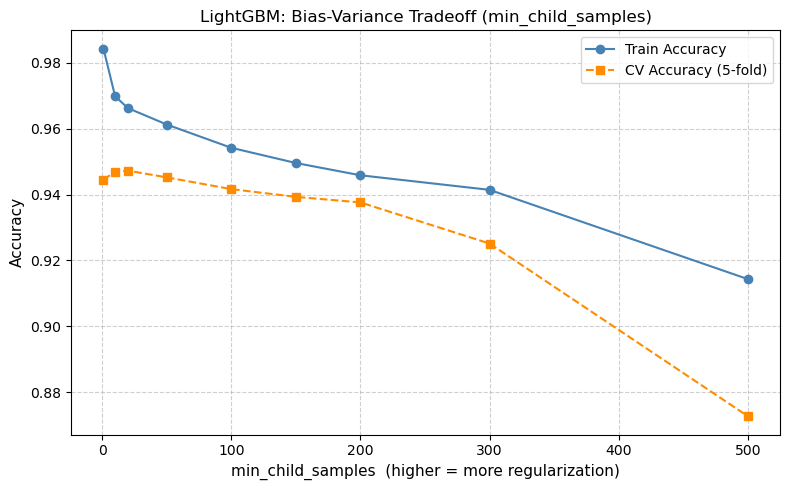

In [165]:
# systematic sweep of min_child_samples - calc_params style 
# keeping depth=7 (GridSearch best), varying min_child_samples to find sweet spot
min_child_values = [1, 10, 20, 50, 100, 150, 200, 300, 500]
lgb_train_accs = []
lgb_cv_accs    = []

for mc in min_child_values:
    # assessing how minimum samples in a leaf node affect accuracy gap
    m = LGBMClassifier(n_estimators=300, max_depth=7, learning_rate=0.2,
                       min_child_samples=mc, random_state=33, verbose=-1)
    m.fit(X_train_tfidf, y_train)
    lgb_train_accs.append(accuracy_score(y_train, m.predict(X_train_tfidf)))
    cv = cross_val_score(
        LGBMClassifier(n_estimators=300, max_depth=7, learning_rate=0.2,
                       min_child_samples=mc, random_state=33, verbose=-1),
        X_train_tfidf, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    lgb_cv_accs.append(cv.mean())
# displaying the gap metrics
print(f"{'min_child_samples':>20} {'Train Acc':>10} {'CV Acc':>10} {'Gap':>8}")
print("-" * 52)
for mc, tr, cv in zip(min_child_values, lgb_train_accs, lgb_cv_accs):
    print(f"{mc:>20} {tr:>10.4f} {cv:>10.4f} {tr-cv:>8.4f}")

# plotting
plt.figure(figsize=(8, 5))
plt.plot(min_child_values, lgb_train_accs, 'o-',  label='Train Accuracy',     color='steelblue')
plt.plot(min_child_values, lgb_cv_accs,    's--', label='CV Accuracy (5-fold)',color='darkorange')
plt.xlabel('min_child_samples  (higher = more regularization)', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('LightGBM: Bias-Variance Tradeoff (min_child_samples)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [167]:
# min_child_samples=20 selected: CV accuracy peaks at 0.9473, gap reduced from 3.98% to 1.90%
lgb_best = LGBMClassifier(
    n_estimators     = 300,
    max_depth        = 7,
    learning_rate    = 0.2,
    min_child_samples= 20,
    random_state     = 33,
    verbose          = -1)
lgb_best.fit(X_train_tfidf, y_train)

lgb_train_pred = lgb_best.predict(X_train_tfidf)
lgb_test_pred  = lgb_best.predict(X_test_tfidf)
lgb_test_proba = lgb_best.predict_proba(X_test_tfidf)[:, 1]

train_acc = accuracy_score(y_train, lgb_train_pred)
test_acc  = accuracy_score(y_test,  lgb_test_pred)

print("Final LightGBM (depth=7, min_child_samples=20) - Training Set Results")
print("=" * 55)
print(classification_report(y_train, lgb_train_pred, target_names=['Benign (0)', 'Malicious (1)']))
print("Final LightGBM (depth=7, min_child_samples=20) - Test Set Results")
print("=" * 55)
print(classification_report(y_test, lgb_test_pred, target_names=['Benign (0)', 'Malicious (1)']))
print(f"Train Acc : {train_acc:.4f}  |  Test Acc : {test_acc:.4f}  |  Gap : {train_acc - test_acc:.4f}")

Final LightGBM (depth=7, min_child_samples=20) - Training Set Results
               precision    recall  f1-score   support

   Benign (0)       0.94      1.00      0.97     15692
Malicious (1)       1.00      0.93      0.97     15693

     accuracy                           0.97     31385
    macro avg       0.97      0.97      0.97     31385
 weighted avg       0.97      0.97      0.97     31385

Final LightGBM (depth=7, min_child_samples=20) - Test Set Results
               precision    recall  f1-score   support

   Benign (0)       0.91      0.98      0.95      3924
Malicious (1)       0.98      0.90      0.94      3923

     accuracy                           0.94      7847
    macro avg       0.95      0.94      0.94      7847
 weighted avg       0.95      0.94      0.94      7847

Train Acc : 0.9663  |  Test Acc : 0.9442  |  Gap : 0.0221


### Model Comparison - Selecting Best Models for Ensemble

In [178]:
# comparing all 4 models on training and test set to justify ensemble base learner selection
# showing both train and test performance to demonstrate overfitting analysis
models       = ['Naive Bayes', 'Logistic Regression', 'Linear SVM', 'LightGBM']
train_preds  = [nb_train_pred, lr_train_pred, svm_train_pred, lgb_train_pred]
test_preds   = [nb_test_pred,  lr_test_pred,  svm_test_pred,  lgb_test_pred]
test_probas  = [nb_best.predict_proba(X_test_tfidf)[:, 1],
                lr_test_proba, svm_test_proba, lgb_test_proba]

print("Model Comparison - Training Set Performance")
print("=" * 85)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 85)
for name, pred in zip(models, train_preds):
    acc  = accuracy_score(y_train, pred)
    prec = precision_score(y_train, pred)
    rec  = recall_score(y_train, pred)
    f1   = f1_score(y_train, pred)
    print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

print()
print("Model Comparison - Test Set Performance")
print("=" * 95)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 95)
for name, pred, proba in zip(models, test_preds, test_probas):
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    auc  = roc_auc_score(y_test, proba)
    print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {auc:>10.4f}")

Model Comparison - Training Set Performance
Model                       Accuracy  Precision     Recall         F1
-------------------------------------------------------------------------------------
Naive Bayes                   0.9349     0.9632     0.9044     0.9329
Logistic Regression           0.9595     0.9859     0.9324     0.9584
Linear SVM                    0.9721     0.9858     0.9580     0.9717
LightGBM                      0.9663     0.9977     0.9347     0.9652

Model Comparison - Test Set Performance
Model                       Accuracy  Precision     Recall         F1    ROC-AUC
-----------------------------------------------------------------------------------------------
Naive Bayes                   0.9029     0.9165     0.8866     0.9013     0.9612
Logistic Regression           0.9420     0.9733     0.9090     0.9400     0.9819
Linear SVM                    0.9433     0.9608     0.9243     0.9422     0.9820
LightGBM                      0.9442     0.9826     0.9044 

### Model 5 - Stacking Ensemble

In [180]:
# stacking classifier using top 3 models as base learners and logistic regression as meta-learner
# base learners are heterogeneous - different algorithm types for better generalization
# meta-learner learns optimal combination of base learner predictions
base_learners = [
    ('lr',  LogisticRegression(C=2.0, max_iter=1000, random_state=33)),
    ('svm', CalibratedClassifierCV(LinearSVC(C=0.5, random_state=33, max_iter=2000))),
    ('lgb', LGBMClassifier(n_estimators=300, max_depth=7, learning_rate=0.2, min_child_samples=20, random_state=33, verbose=-1))]
# using Logistic Regression as the meta-learner to combine base model probabilities
stack_clf = StackingClassifier(
    estimators      = base_learners,
    final_estimator = LogisticRegression(C=1.0, max_iter=1000, random_state=33),
    cv              = 5,
    stack_method    = 'predict_proba',
    n_jobs          = -1)

stack_clf.fit(X_train_tfidf, y_train)
# reviewing ensemble training results
stack_train_pred = stack_clf.predict(X_train_tfidf)
print("Stacking Ensemble - Training Set Results")
print("=" * 55)
print(classification_report(y_train, stack_train_pred, target_names=['Benign (0)', 'Malicious (1)']))
# reviewing ensemble test results
stack_test_pred  = stack_clf.predict(X_test_tfidf)
print("Stacking Ensemble - Test Set Results")
print("=" * 55)
print(classification_report(y_test, stack_test_pred, target_names=['Benign (0)', 'Malicious (1)']))

stack_test_proba = stack_clf.predict_proba(X_test_tfidf)[:, 1]

train_acc = accuracy_score(y_train, stack_train_pred)
test_acc  = accuracy_score(y_test,  stack_test_pred)
print(f"Train Acc : {train_acc:.4f}  |  Test Acc : {test_acc:.4f}  |  Gap : {train_acc - test_acc:.4f}")

Stacking Ensemble - Training Set Results
               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97     15692
Malicious (1)       0.99      0.95      0.97     15693

     accuracy                           0.97     31385
    macro avg       0.97      0.97      0.97     31385
 weighted avg       0.97      0.97      0.97     31385

Stacking Ensemble - Test Set Results
               precision    recall  f1-score   support

   Benign (0)       0.93      0.98      0.95      3924
Malicious (1)       0.97      0.92      0.95      3923

     accuracy                           0.95      7847
    macro avg       0.95      0.95      0.95      7847
 weighted avg       0.95      0.95      0.95      7847

Train Acc : 0.9717  |  Test Acc : 0.9498  |  Gap : 0.0219


### Comparision of all models

#### ROC-AUC comparison plot for all 5 models

<Figure size 900x600 with 0 Axes>

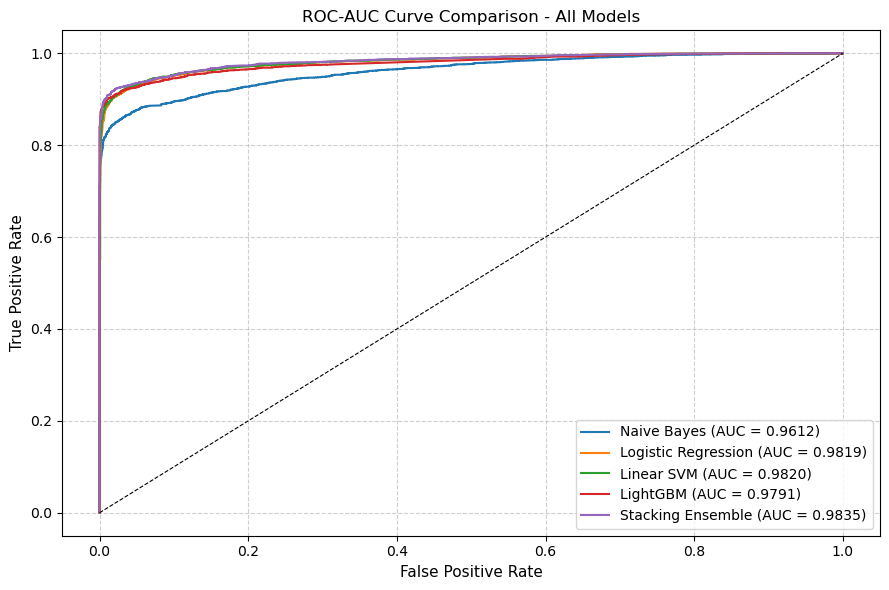

In [185]:
# comparing all models using ROC (Receiver Operating Characteristic) curves
# higher Area Under the Curve (AUC) indicates better ability to distinguish between classes
models_roc = {
    'Naive Bayes'         : nb_best.predict_proba(X_test_tfidf)[:, 1],
    'Logistic Regression' : lr_test_proba,
    'Linear SVM'          : svm_test_proba,
    'LightGBM'            : lgb_test_proba,
    'Stacking Ensemble'   : stack_test_proba}

plt.figure(figsize=(9, 6))
for name, proba in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")
# plotting
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC-AUC Curve Comparison - All Models', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [191]:
# final comparison of all 5 models on training and test set
models_all      = ['Naive Bayes', 'Logistic Regression', 'Linear SVM', 'LightGBM', 'Stacking Ensemble']
train_preds_all = [nb_train_pred, lr_train_pred, svm_train_pred, lgb_train_pred, stack_train_pred]
test_preds_all  = [nb_test_pred,  lr_test_pred,  svm_test_pred,  lgb_test_pred,  stack_test_pred]
test_probas_all = [nb_best.predict_proba(X_test_tfidf)[:, 1],
                   lr_test_proba, svm_test_proba, lgb_test_proba, stack_test_proba]

print("Final Model Comparison - Training Set Performance")
print("=" * 85)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 85)
for name, pred in zip(models_all, train_preds_all):
    acc  = accuracy_score(y_train, pred)
    prec = precision_score(y_train, pred)
    rec  = recall_score(y_train, pred)
    f1   = f1_score(y_train, pred)
    print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

print()
print("Final Model Comparison - Test Set Performance")
print("=" * 95)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 95)
for name, pred, proba in zip(models_all, test_preds_all, test_probas_all):
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    auc  = roc_auc_score(y_test, proba)
    print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {auc:>10.4f}")

Final Model Comparison - Training Set Performance
Model                       Accuracy  Precision     Recall         F1
-------------------------------------------------------------------------------------
Naive Bayes                   0.9349     0.9632     0.9044     0.9329
Logistic Regression           0.9595     0.9859     0.9324     0.9584
Linear SVM                    0.9721     0.9858     0.9580     0.9717
LightGBM                      0.9663     0.9977     0.9347     0.9652
Stacking Ensemble             0.9717     0.9909     0.9521     0.9711

Final Model Comparison - Test Set Performance
Model                       Accuracy  Precision     Recall         F1    ROC-AUC
-----------------------------------------------------------------------------------------------
Naive Bayes                   0.9029     0.9165     0.8866     0.9013     0.9612
Logistic Regression           0.9420     0.9733     0.9090     0.9400     0.9819
Linear SVM                    0.9433     0.9608     0.9243